# ML Assignment – Twitter Sentiment Analysis (Text Classification)

**Algorithm:** Naive Bayes
**Task type:** Multi-class classification (Positive / Negative / Neutral / Irrelevant)
**Dataset:** [Twitter Entity Sentiment Analysis](https://www.kaggle.com/datasets/jp797498e/twitter-entity-sentiment-analysis) (used via the linked notebook: https://www.kaggle.com/code/abdallahwagih/twitter-sentiment-analysis)

---

### Student details
- Name: `<fill in>` | Last 4 digits of ID: `<fill in>`
- (add a line per group member, per assignment instructions)

### AI Chatbot usage
> Fill this in as you go: which prompts you used, for what purpose, and links to any chat transcripts you want to reference. The assignment requires you to show understanding, not just paste AI output.

- Prompt 1: `<describe>` — used for: `<what you used it for>`


## Part 1 — Introduction & Dataset

**Problem:** Classify tweets into one of four sentiment classes — *Positive*, *Negative*, *Neutral*, *Irrelevant* — based on the tweet text. Each row also has an `entity` (the brand/topic the tweet is about, e.g. Borderlands, Amazon, Microsoft) and a numeric `id`.

**Dataset:** 74,682 labeled training tweets and 1,758 labeled validation tweets, spanning 32 different entities. The files have **no header row**; columns in order are: `id, entity, sentiment, text`. This is a **multi-class classification problem with no single "central" class**, so per the assignment we'll report **macro-average F1** as our quality metric.

*(Expand this paragraph with a bit more detail for your submission — e.g. why you picked this dataset, what makes it interesting/challenging.)*


## Setup

In [5]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedKFold

pd.set_option("display.max_colwidth", 120)
RANDOM_STATE = 42


### Load the dataset

The assignment says: **do not re-split train/test yourselves** — use the provided training and validation files as-is (training file = your train set, validation file = your test set).

In [6]:
TRAIN_PATH = "twitter_training.csv"
TEST_PATH  = "twitter_validation.csv"

COLUMN_NAMES = ["id", "entity", "sentiment", "text"]

train_df = pd.read_csv(TRAIN_PATH, header=None, names=COLUMN_NAMES)
test_df  = pd.read_csv(TEST_PATH,  header=None, names=COLUMN_NAMES)

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)


Train shape: (74682, 4)
Test shape:  (1000, 4)


In [7]:
# Required by the assignment: show the first 5 rows of each dataset
train_df.head()


,id,entity,sentiment,text
0,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
1,2401,Borderlands,Positive,"I am coming to the borders and I will kill you all,"
2,2401,Borderlands,Positive,"im getting on borderlands and i will kill you all,"
3,2401,Borderlands,Positive,"im coming on borderlands and i will murder you all,"
4,2401,Borderlands,Positive,"im getting on borderlands 2 and i will murder you me all,"


In [8]:
test_df.head()


,id,entity,sentiment,text
0,3364,Facebook,Irrelevant,"I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translate..."
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects claims company acted like a 'drug dealer' bbc.co.uk/news/av/busine…
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it functions so poorly on my @SamsungUS Chromebook? 🙄
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking, it's a truly awful game."
4,4433,Google,Neutral,Now the President is slapping Americans in the face that he really did commit an unlawful act after his acquittal! ...


### Basic exploration

Class distribution (train):
sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

Class distribution (test):
sentiment
Neutral       285
Positive      277
Negative      266
Irrelevant    172
Name: count, dtype: int64


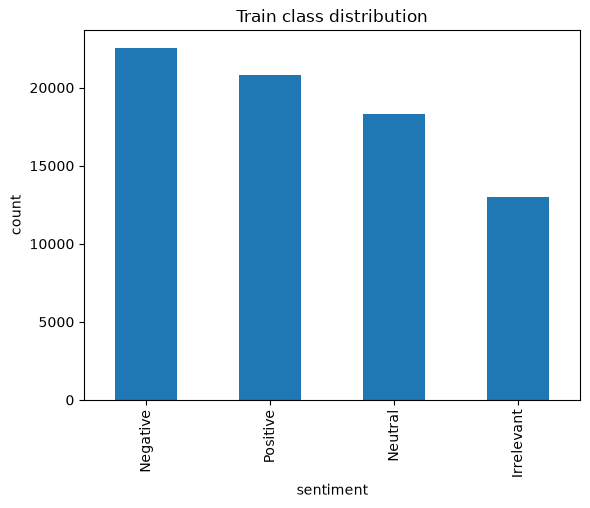

In [9]:
print("Class distribution (train):")
print(train_df["sentiment"].value_counts())
print()
print("Class distribution (test):")
print(test_df["sentiment"].value_counts())

train_df["sentiment"].value_counts().plot(kind="bar", title="Train class distribution")
plt.ylabel("count")
plt.show()


In [10]:
print("Missing values (train):")
print(train_df.isna().sum())
print()
print("Missing values (test):")
print(test_df.isna().sum())


Missing values (train):
id             0
entity         0
sentiment      0
text         686
dtype: int64

Missing values (test):
id           0
entity       0
sentiment    0
text         0
dtype: int64


In [11]:
# Drop rows with missing text (there are ~686 in train) — decide & justify this in your write-up
train_df = train_df.dropna(subset=["text"]).reset_index(drop=True)
test_df  = test_df.dropna(subset=["text"]).reset_index(drop=True)

# Drop exact duplicate rows (common issue in this dataset — check + justify)
print("Duplicate rows in train:", train_df.duplicated().sum())
train_df = train_df.drop_duplicates().reset_index(drop=True)

print("Train shape after cleaning:", train_df.shape)
print("Test shape after cleaning: ", test_df.shape)


Duplicate rows in train: 2340
Train shape after cleaning: (71656, 4)
Test shape after cleaning:  (1000, 4)


## Part 2 — Feature Engineering (text preprocessing)

Basic text cleaning + vectorization pipeline. This is a starting point — the assignment wants you to **show it working on 2–3 examples** on both train and test, and (for bonus points) to try multiple feature-engineering variants with grid search + k-fold CV.

In [12]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)      # remove URLs
    text = re.sub(r"@\w+", " ", text)                   # remove mentions
    text = re.sub(r"[^a-z\s]", " ", text)                # keep letters only
    text = re.sub(r"\s+", " ", text).strip()             # collapse whitespace
    return text

train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"]  = test_df["text"].apply(clean_text)

# Show the effect on 3 examples, as required by the assignment
for original, cleaned in list(zip(train_df["text"], train_df["clean_text"]))[:3]:
    print("RAW:  ", original)
    print("CLEAN:", cleaned)
    print()


RAW:   im getting on borderlands and i will murder you all ,
CLEAN: im getting on borderlands and i will murder you all

RAW:   I am coming to the borders and I will kill you all,
CLEAN: i am coming to the borders and i will kill you all

RAW:   im getting on borderlands and i will kill you all,
CLEAN: im getting on borderlands and i will kill you all



In [13]:
# Vectorize (Bag-of-Words / CountVectorizer works well as the classic pairing with Naive Bayes;
# TF-IDF is worth comparing against — good candidate for your Part 6a grid search).
vectorizer = CountVectorizer(stop_words="english", max_features=5000)

X_train = vectorizer.fit_transform(train_df["clean_text"])
y_train = train_df["sentiment"]

X_test = vectorizer.transform(test_df["clean_text"])
y_test = test_df["sentiment"]

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)


X_train shape: (71656, 5000)
X_test shape:  (1000, 5000)


## Part 3 — Learning Algorithm: Naive Bayes

We use **Multinomial Naive Bayes**, the standard choice for text classification with word-count / TF-IDF features. It assumes each feature (word) contributes independently to the class log-probability, which is a strong but often surprisingly effective assumption for text.

Key hyperparameter: **`alpha`** — the Laplace/Lidstone smoothing parameter, which avoids zero probabilities for words unseen in a class during training. You should experiment with several values of `alpha` for your Part 6a bonus (e.g. 0.1, 0.5, 1.0, 2.0).

Below: a small wrapper with explicit `train()` and `predict()` functions, as required.

In [14]:
def train_naive_bayes(X, y, alpha: float = 1.0) -> MultinomialNB:
    """Train a Multinomial Naive Bayes classifier."""
    model = MultinomialNB(alpha=alpha)
    model.fit(X, y)
    return model

def predict(model: MultinomialNB, X):
    """Return predicted class labels for X."""
    return model.predict(X)


## Part 4 — Training (run the flow)

In [15]:
nb_model = train_naive_bayes(X_train, y_train, alpha=1.0)
print("Model trained on", X_train.shape[0], "examples.")


Model trained on 71656 examples.


## Part 5 — Prediction & Quality Evaluation on the Test Set

This is multi-class classification with no single central class, so we report **macro-average F1** (as specified by the assignment), plus accuracy and a full classification report / confusion matrix for context.

In [16]:
y_pred = predict(nb_model, X_test)

# Required: show the first 5 predictions on the test set
results_preview = test_df[["text", "sentiment"]].copy()
results_preview["predicted"] = y_pred
results_preview.head(5)


,text,sentiment,predicted
0,"I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translate...",Irrelevant,Irrelevant
1,BBC News - Amazon boss Jeff Bezos rejects claims company acted like a 'drug dealer' bbc.co.uk/news/av/busine…,Neutral,Neutral
2,@Microsoft Why do I pay for WORD when it functions so poorly on my @SamsungUS Chromebook? 🙄,Negative,Negative
3,"CSGO matchmaking is so full of closet hacking, it's a truly awful game.",Negative,Negative
4,Now the President is slapping Americans in the face that he really did commit an unlawful act after his acquittal! ...,Neutral,Neutral


In [17]:
macro_f1 = f1_score(y_test, y_pred, average="macro")
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy:       {acc:.4f}")
print(f"Macro-avg F1:   {macro_f1:.4f}")
print()
print(classification_report(y_test, y_pred))


Accuracy:       0.7000
Macro-avg F1:   0.6940

              precision    recall  f1-score   support

  Irrelevant       0.70      0.62      0.66       172
    Negative       0.68      0.77      0.72       266
     Neutral       0.76      0.60      0.67       285
    Positive       0.68      0.79      0.73       277

    accuracy                           0.70      1000
   macro avg       0.70      0.69      0.69      1000
weighted avg       0.71      0.70      0.70      1000



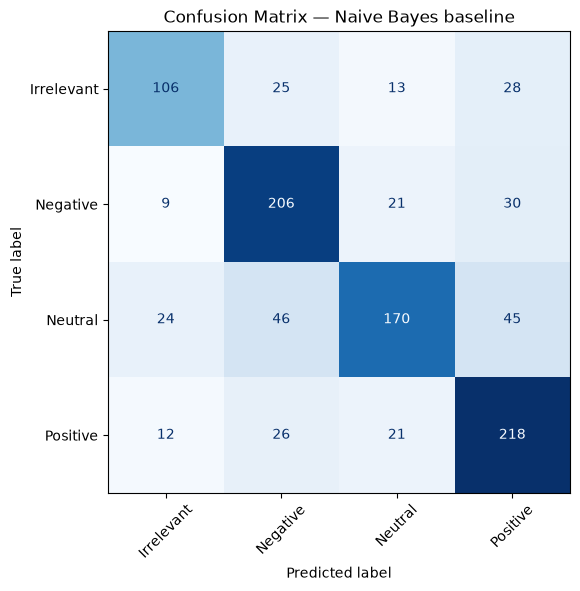

In [18]:
labels = sorted(y_train.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix — Naive Bayes baseline")
plt.xticks(rotation=45)
plt.show()


## Where to go from here

You now have a working end-to-end baseline (load → clean → vectorize → train → predict → evaluate). Suggested next steps, mapped to the assignment's sections:

1. **Part 2 polish (feature engineering):** try stemming/lemmatization (`nltk` or `spaCy`), TF-IDF vs. CountVectorizer, n-grams (`ngram_range=(1,2)`), removing the `entity` column vs. concatenating it into the text as a feature.
2. **Part 3 polish:** briefly explain *why* Naive Bayes works the way it does (Bayes' theorem, conditional independence assumption) — you'll need this for your video/presentation.
3. **Part 6a (bonus, up to 25 pts):** set up a **grid search × 5-fold cross-validation** over combinations of:
   - feature engineering choices (CountVectorizer vs TF-IDF, `max_features`, `ngram_range`, stop words on/off)
   - `alpha` values for `MultinomialNB`
   Collect all results into a `pandas.DataFrame`, report the best combination's average macro-F1 across folds, then retrain on the *full* training set using that combination and re-evaluate on the test set (see cells below for a skeleton).
4. **Part 6b (bonus, up to 10 pts):** the classes aren't perfectly balanced (Negative 22.5k vs Irrelevant 13k) — consider oversampling/undersampling (e.g. `imblearn`) and document the effect.
5. **Part 6c (bonus, up to 10 pts):** explainability — e.g. look at `model.feature_log_prob_` to find the most indicative words per class, or use `SHAP`/`eli5` on the pipeline.
6. Write the intro paragraph, the AI-prompt log, and prep your ~5 minute video/presentation.

### Grid search + k-fold skeleton (for step 3 above)


In [ ]:
from sklearn.pipeline import Pipeline

# Example: a small grid over vectorizer type/size and alpha.
# Expand this dict with more feature-engineering / hyperparameter options as you experiment.
param_grid = [
    {"vectorizer": CountVectorizer(stop_words="english", max_features=mf), "alpha": a}
    for mf in [3000, 5000]
    for a in [0.5, 1.0]
]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_text = train_df["clean_text"].values
y_all = train_df["sentiment"].values

grid_results = []

for params in param_grid:
    fold_scores = []
    for train_idx, val_idx in skf.split(X_text, y_all):
        vec = params["vectorizer"]
        X_tr = vec.fit_transform(X_text[train_idx])
        X_val = vec.transform(X_text[val_idx])
        model = train_naive_bayes(X_tr, y_all[train_idx], alpha=params["alpha"])
        preds = predict(model, X_val)
        fold_scores.append(f1_score(y_all[val_idx], preds, average="macro"))

    grid_results.append({
        "max_features": params["vectorizer"].max_features,
        "alpha": params["alpha"],
        "mean_macro_f1": np.mean(fold_scores),
        "std_macro_f1": np.std(fold_scores),
    })

grid_df = pd.DataFrame(grid_results).sort_values("mean_macro_f1", ascending=False)
grid_df


In [ ]:
best_params = grid_df.iloc[0]
print("Best combination:")
print(best_params)

# Next: retrain on the FULL training set with this combination, then re-evaluate on test_df
# (mirrors what you already did in Parts 4-5 above).
